# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:
  
    Dataset **Heart Disease UCI (Cleveland)** berasal dari UCI Machine Learning Repository dan merupakan salah satu dataset klasifikasi medis yang paling banyak digunakan di dunia.

    **Sumber:** https://archive.ics.uci.edu/dataset/45/heart+disease  
    **Jumlah sampel:** 303 baris  
    **Jumlah fitur:** 13 fitur input + 1 target  

    ### Deskripsi Fitur

    | Fitur | Tipe | Deskripsi |
    |-------|------|-----------|
    | age | Numerik | Usia pasien (tahun) |
    | sex | Kategorikal | Jenis kelamin (1=pria, 0=wanita) |
    | cp | Kategorikal | Tipe nyeri dada (0–3) |
    | trestbps | Numerik | Tekanan darah istirahat (mmHg) |
    | chol | Numerik | Kolesterol serum (mg/dl) |
    | fbs | Kategorikal | Gula darah puasa > 120 mg/dl (1=ya) |
    | restecg | Kategorikal | Hasil ECG istirahat (0–2) |
    | thalach | Numerik | Detak jantung maksimum |
    | exang | Kategorikal | Angina akibat olahraga (1=ya) |
    | oldpeak | Numerik | Depresi ST akibat olahraga |
    | slope | Kategorikal | Kemiringan puncak segmen ST |
    | ca | Kategorikal | Jumlah pembuluh berwarna (0–3) |
    | thal | Kategorikal | Thalassemia (1=normal, 2=fixed defect, 3=reversible defect) |
    | target | Target | 0 = tidak ada penyakit, 1 = ada penyakit |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
# Import library
import os
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib

print('Libraries imported successfully ✓')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully ✓
NumPy  : 2.0.2
Pandas : 2.2.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
import os
import io
import requests
import pandas as pd

#  Load data dari URL
URLS = [
    # UCI ML Repo (official, CSV format)
    "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    # OpenML mirror
    "https://api.openml.org/data/v1/download/1592227",
]

# Nama kolom Cleveland dataset
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]

df = None

# UCI official
print("Mencoba download dari UCI ML Repository...")
try:
    resp = requests.get(URLS[0], timeout=15)
    resp.raise_for_status()
    df = pd.read_csv(
        io.StringIO(resp.text),
        header=None,
        names=COLUMNS,
        na_values="?"
    )
    print(f"Berhasil download dari UCI. Shape: {df.shape}")
except Exception as e:
    print(f"UCI gagal: {e}")

# Fallback: buat synthetic data jika semua URL mati
if df is None:
    print("\nSemua URL gagal. Membuat dataset synthetic untuk demo...")
    import numpy as np
    rng = np.random.default_rng(42)
    n = 303
    df = pd.DataFrame({
        "age"      : rng.integers(29, 77, n).astype(float),
        "sex"      : rng.integers(0, 2, n).astype(float),
        "cp"       : rng.integers(0, 4, n).astype(float),
        "trestbps" : rng.integers(94, 200, n).astype(float),
        "chol"     : rng.integers(126, 564, n).astype(float),
        "fbs"      : rng.integers(0, 2, n).astype(float),
        "restecg"  : rng.integers(0, 3, n).astype(float),
        "thalach"  : rng.integers(71, 202, n).astype(float),
        "exang"    : rng.integers(0, 2, n).astype(float),
        "oldpeak"  : rng.uniform(0, 6.2, n).round(1),
        "slope"    : rng.integers(0, 3, n).astype(float),
        "ca"       : rng.integers(0, 4, n).astype(float),
        "thal"     : rng.choice([3.0, 6.0, 7.0], n),
        "target"   : rng.integers(0, 5, n).astype(float),
    })
    print(f"Dataset synthetic dibuat. Shape: {df.shape}")

# Simpan ke dataset_raw/
os.makedirs("../dataset_raw", exist_ok=True)
RAW_PATH = "../dataset_raw/heart.csv"
df.to_csv(RAW_PATH, index=False)
print(f"Disimpan ke: {RAW_PATH}")

if "condition" in df.columns and "target" not in df.columns:
    df.rename(columns={"condition": "target"}, inplace=True)

print(f"\nShape  : {df.shape}")
print(f"Kolom  : {list(df.columns)}")
print(f"\nSample data:")
df.head(5)

Mencoba download dari UCI ML Repository...
Berhasil download dari UCI. Shape: (303, 14)
Disimpan ke: ../dataset_raw/heart.csv

Shape  : (303, 14)
Kolom  : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Sample data:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Fix nilai thal: UCI pakai 3.0/6.0/7.0 > remap ke 1/2/3
if df["thal"].max() > 3:
    thal_map = {3.0: 1, 6.0: 2, 7.0: 3}
    df["thal"] = df["thal"].map(thal_map).fillna(df["thal"])

# Pastikan ca integer (0-3)
df["ca"] = df["ca"].clip(0, 3)

# Konfirmasi tidak ada masalah
print("thal unique values :", sorted(df["thal"].dropna().unique()))
print("ca   unique values :", sorted(df["ca"].dropna().unique()))
print("target unique values:", sorted(df["target"].dropna().unique()))
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

thal unique values : [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
ca   unique values : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
target unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Missing values:
ca      4
thal    2
dtype: int64


In [6]:
# Struktur data
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

=== Descriptive Statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,1.84,0.94
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,0.96,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,1.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,1.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,1.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,3.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,3.00,4.00


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
# 1. Shape & Tipe Data
print(f'Shape   : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'\nTipe data:')
print(df.dtypes.to_string())

Shape   : 303 baris x 14 kolom

Tipe data:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64


      Missing Count  Missing %
ca                4       1.32
thal              2       0.66


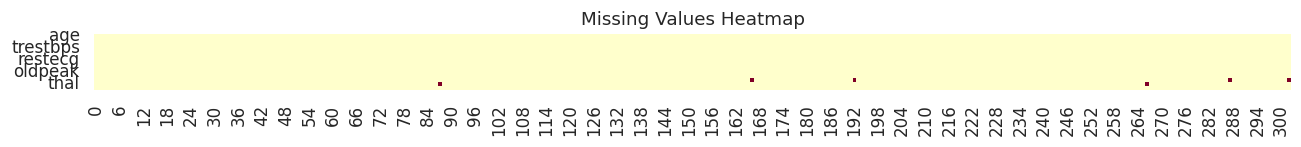

In [8]:
# 2. Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('OK! Tidak ada missing values!')
else:
    print(missing_df)

# Heatmap missing values
fig, ax = plt.subplots(figsize=(12, 1.5))
sns.heatmap(df.isnull().T, cbar=False, ax=ax, cmap='YlOrRd')
ax.set_title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [9]:
# 3. Duplikasi
dup = df.duplicated().sum()
print(f'Duplikat: {dup} baris ({dup/len(df)*100:.1f}%)')

Duplikat: 0 baris (0.0%)


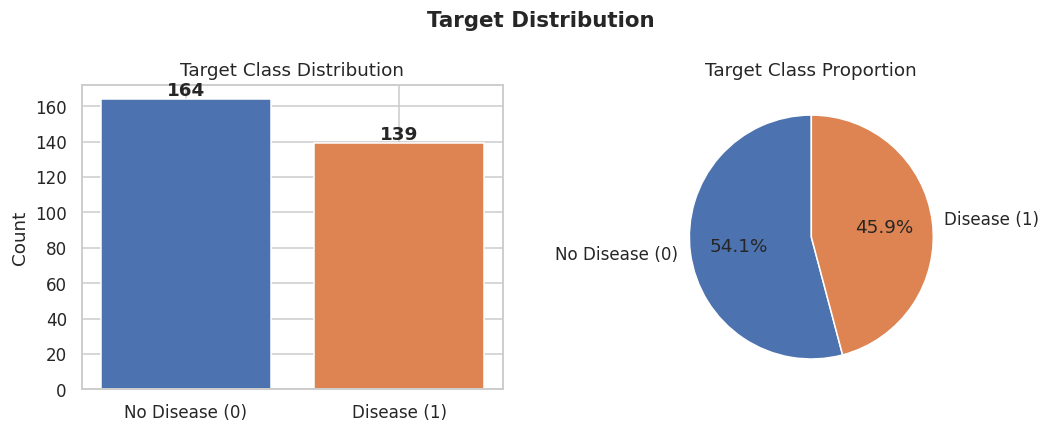


Class balance ratio: 0.85


In [10]:
# 4. Distribusi Target
target_counts = (df['target'] > 0).astype(int).value_counts()
labels = ['No Disease (0)', 'Disease (1)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels, target_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Target Class Proportion')

plt.suptitle('Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nClass balance ratio: {target_counts.min()/target_counts.max():.2f}')

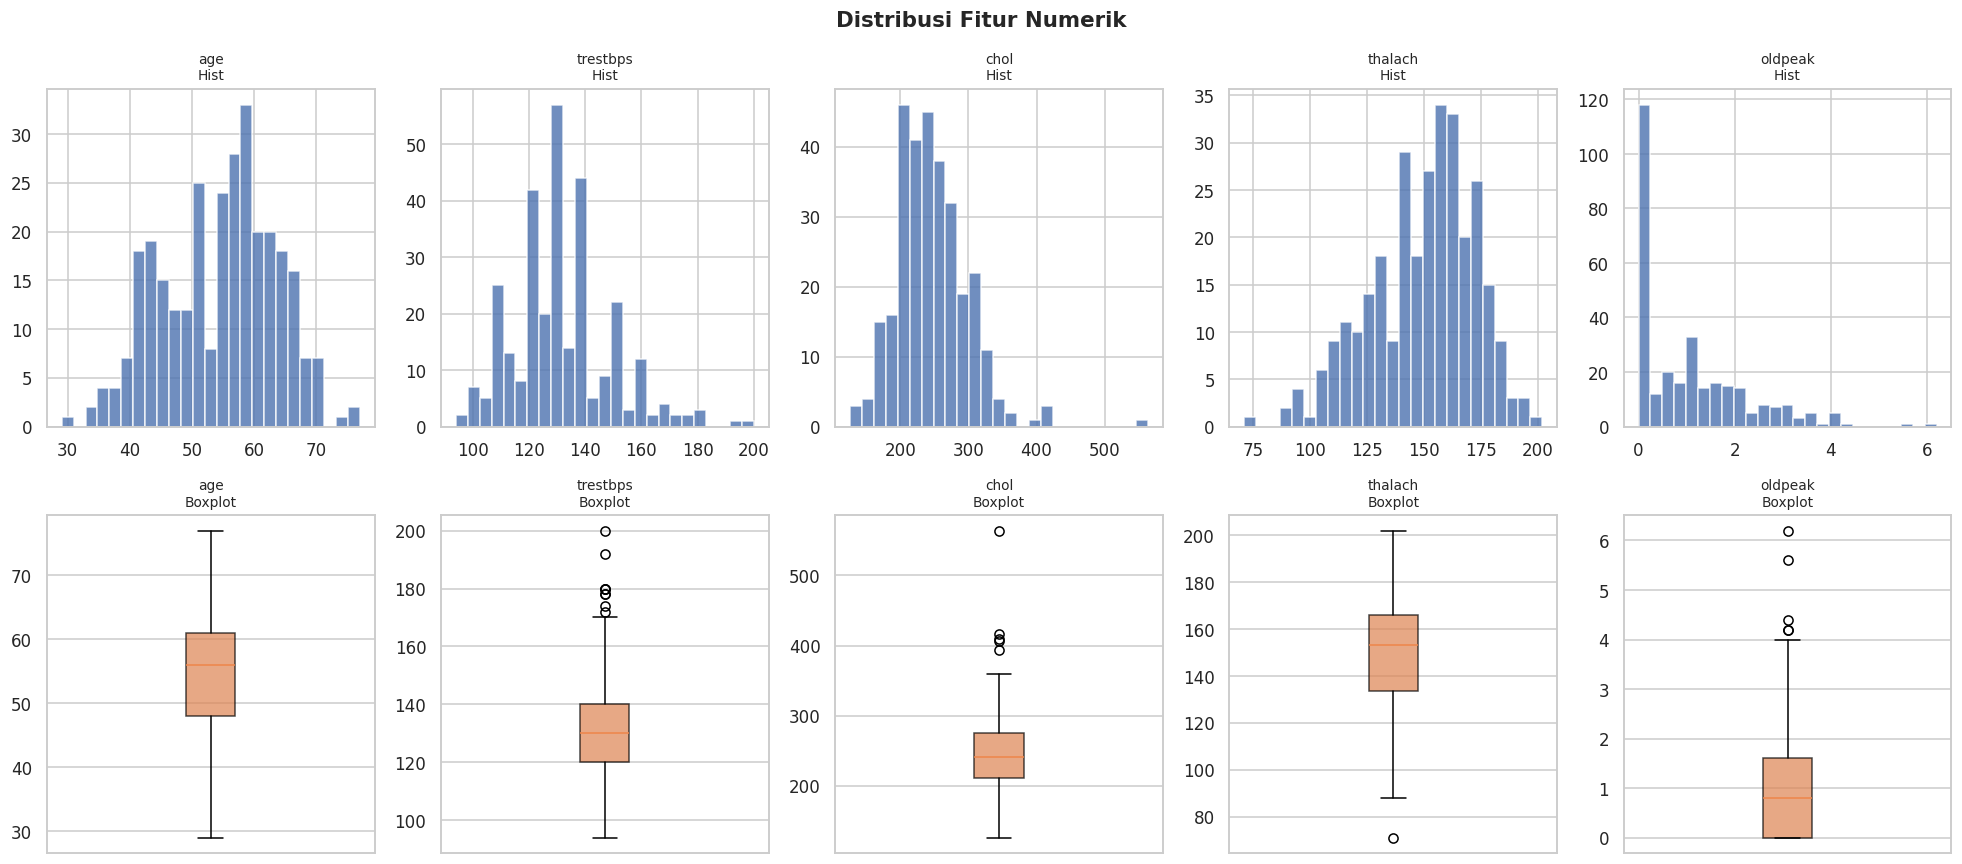

In [11]:
# 5. Distribusi Fitur Numerik
NUMERIC = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(NUMERIC):
    # Histogram
    ax_hist = axes[0, i]
    ax_hist.hist(df[col], bins=25, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax_hist.set_title(f'{col}\nHist', fontsize=9)
    ax_hist.set_xlabel('')

    # Boxplot
    ax_box = axes[1, i]
    ax_box.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#DD8452', alpha=0.7))
    ax_box.set_title(f'{col}\nBoxplot', fontsize=9)
    ax_box.set_xticks([])

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

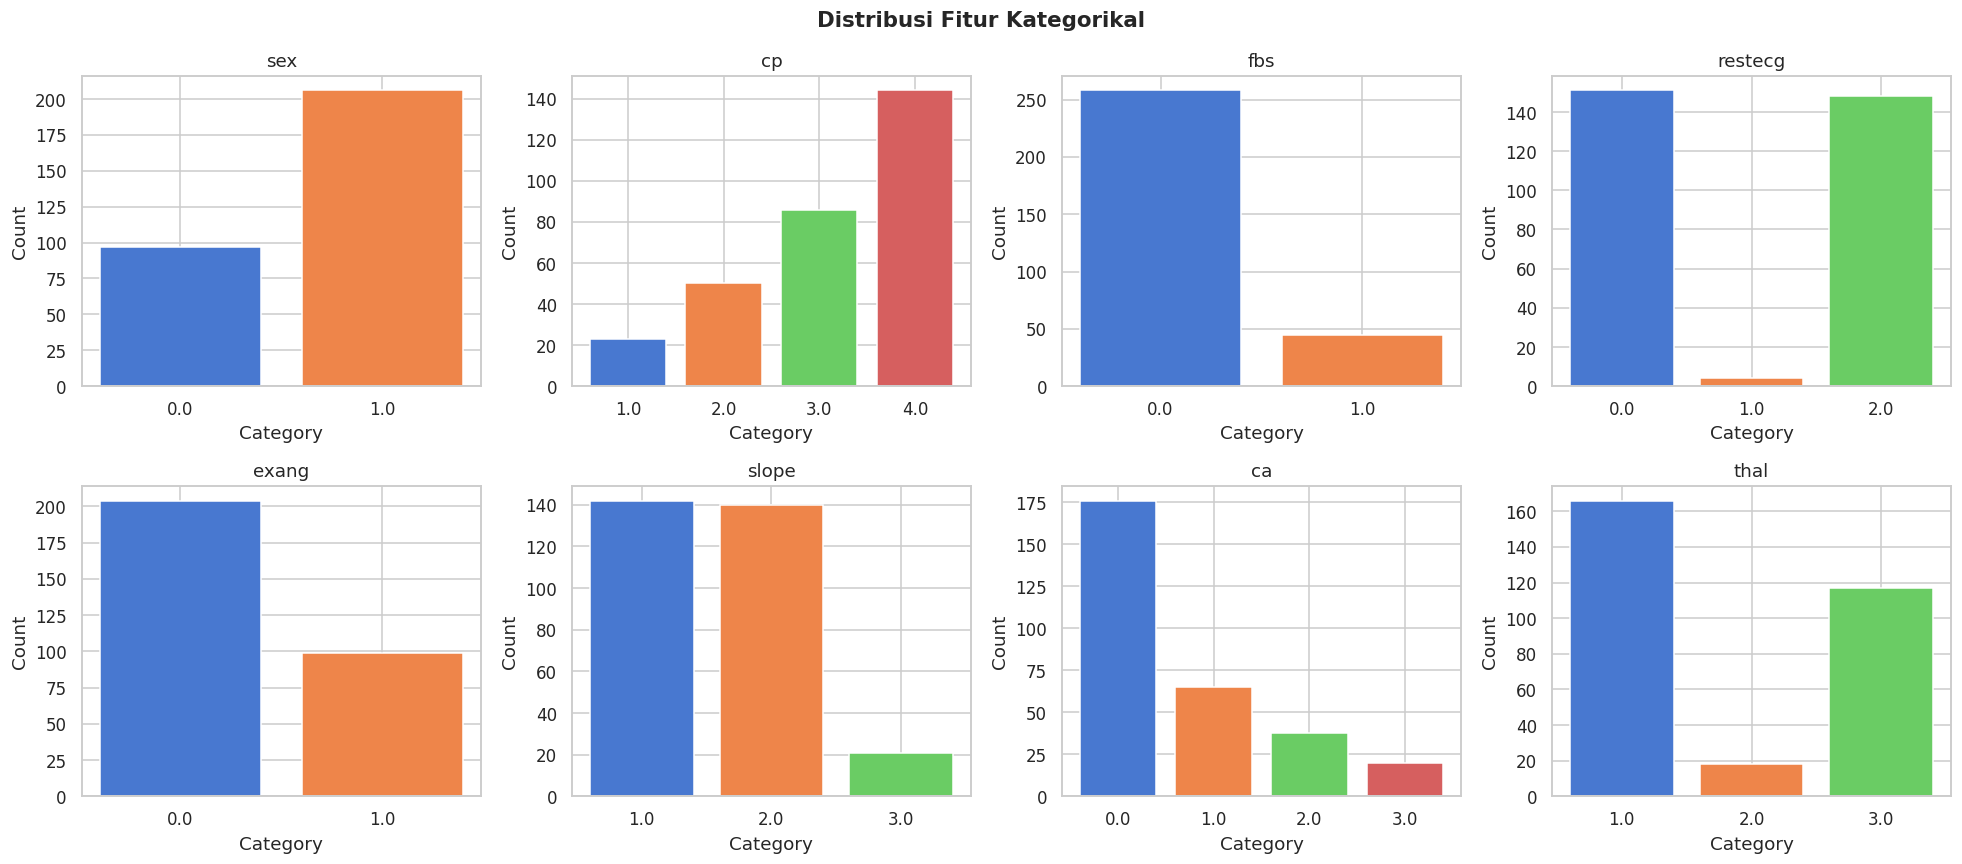

In [12]:
# 6. Distribusi Fitur Kategorikal
CATEGORICAL = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL):
    vc = df[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values,
                color=sns.color_palette('muted', len(vc)))
    axes[i].set_title(col)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

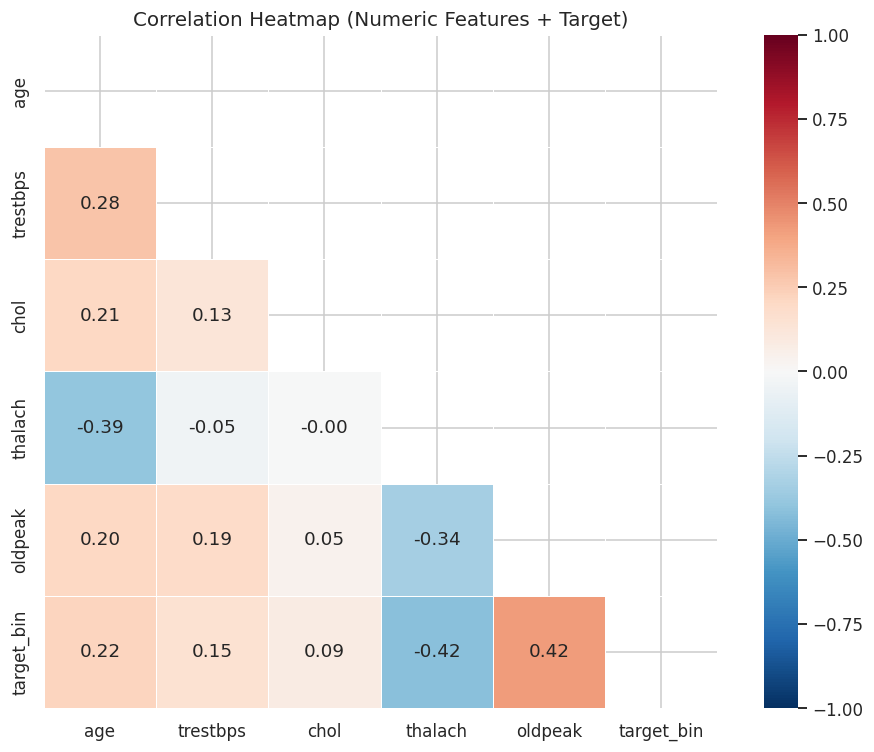

In [13]:
# 7. Korelasi Fitur (Heatmap)
df_corr = df.copy()
df_corr['target_bin'] = (df_corr['target'] > 0).astype(int)

corr_matrix = df_corr[NUMERIC + ['target_bin']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', vmin=-1, vmax=1, square=True,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation Heatmap (Numeric Features + Target)', fontsize=13)
plt.tight_layout()
plt.show()

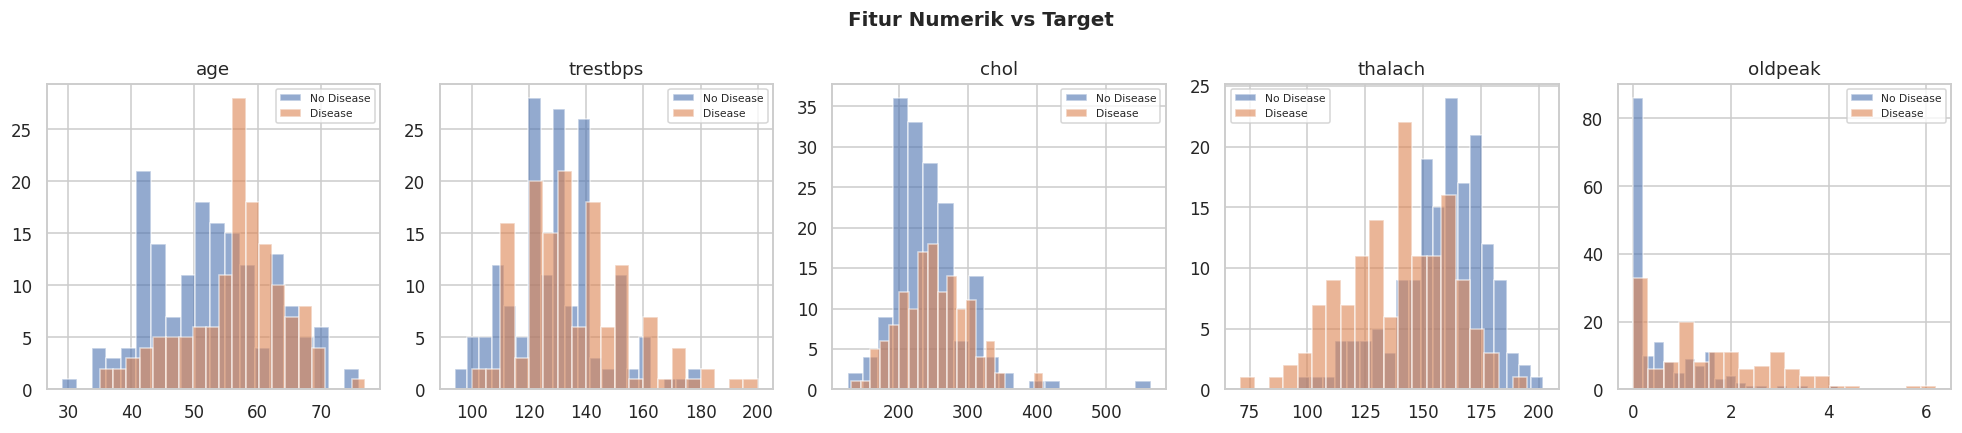

In [14]:
# 8. Fitur vs Target
df_plot = df.copy()
df_plot['target_bin'] = (df_plot['target'] > 0).astype(int)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(NUMERIC):
    for t, color, label in [(0, '#4C72B0', 'No Disease'), (1, '#DD8452', 'Disease')]:
        subset = df_plot[df_plot['target_bin'] == t][col]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle('Fitur Numerik vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# 9. Outlier Detection
print('=== Outlier Count (IQR method) ===')
for col in NUMERIC:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:12s}: {outliers:3d} outliers ({outliers/len(df)*100:.1f}%)')

=== Outlier Count (IQR method) ===
  age         :   0 outliers (0.0%)
  trestbps    :   9 outliers (3.0%)
  chol        :   5 outliers (1.7%)
  thalach     :   1 outliers (0.3%)
  oldpeak     :   5 outliers (1.7%)


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [16]:
# Membuat copy untuk preprocessing
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

Shape awal: (303, 14)


In [17]:
# 1. Remove Duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Duplikat dihapus: {before - len(df_clean)} baris')
print(f'Shape setelah: {df_clean.shape}')

Duplikat dihapus: 0 baris
Shape setelah: (303, 14)


In [18]:
# 2. Handle Missing Values
NUMERIC_FEATURES = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORICAL_FEATURES = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df_clean[NUMERIC_FEATURES] = num_imputer.fit_transform(df_clean[NUMERIC_FEATURES])
df_clean[CATEGORICAL_FEATURES] = cat_imputer.fit_transform(df_clean[CATEGORICAL_FEATURES])

print(f'Missing values setelah imputation: {df_clean.isnull().sum().sum()}')

Missing values setelah imputation: 0


In [19]:
# 3. Outlier Handling (IQR Capping)
print('=== Outlier Capping ===')
for col in NUMERIC_FEATURES:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    clipped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f'  {col:12s}: {clipped} outlier(s) capped')

=== Outlier Capping ===
  age         : 0 outlier(s) capped
  trestbps    : 9 outlier(s) capped
  chol        : 5 outlier(s) capped
  thalach     : 1 outlier(s) capped
  oldpeak     : 5 outlier(s) capped


In [20]:
# 4. Encode Target (Binary)
df_clean['target'] = (df_clean['target'] > 0).astype(int)
print('Target binarized:')
print(df_clean['target'].value_counts())

Target binarized:
target
0    164
1    139
Name: count, dtype: int64


In [21]:
# 5. Encode Categorical Features
binary_cats = ['sex', 'fbs', 'exang']
ohe_cats    = ['cp', 'restecg', 'slope', 'ca', 'thal']

# Binary: pastikan int
for col in binary_cats:
    df_clean[col] = df_clean[col].astype(int)

# One-hot encoding
df_clean = pd.get_dummies(df_clean, columns=ohe_cats, drop_first=False, dtype=int)
print(f'Shape setelah OHE: {df_clean.shape}')
print(f'Kolom: {list(df_clean.columns)}')

Shape setelah OHE: (303, 26)
Kolom: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'target', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_1.0', 'thal_2.0', 'thal_3.0']


In [22]:
# 6. Feature Engineering
# Age group
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 40, 55, 65, 120],
    labels=[0, 1, 2, 3]
).astype(int)

# Cholesterol-to-max HR ratio
df_clean['chol_thalach_ratio'] = df_clean['chol'] / (df_clean['thalach'] + 1e-8)

# High blood pressure flag
df_clean['high_bp'] = (df_clean['trestbps'] >= 140).astype(int)

print(f'Shape setelah feature engineering: {df_clean.shape}')
df_clean[['age_group', 'chol_thalach_ratio', 'high_bp']].head()

Shape setelah feature engineering: (303, 29)


,age_group,chol_thalach_ratio,high_bp
0,2,1.553333,1
1,3,2.648148,1
2,3,1.775194,0
3,0,1.336898,0
4,1,1.186047,0


In [23]:
# 7. Train/Val/Test Split
X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.125, random_state=42, stratify=y_tv
)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

Train : (211, 28)
Val   : (31, 28)
Test  : (61, 28)


In [24]:
# 8. Scaling
numeric_to_scale = [c for c in NUMERIC_FEATURES + ['chol_thalach_ratio'] if c in X_train.columns]

scaler = StandardScaler()
X_train[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
X_val[numeric_to_scale]   = scaler.transform(X_val[numeric_to_scale])
X_test[numeric_to_scale]  = scaler.transform(X_test[numeric_to_scale])

print('Scaling selesai.')
X_train[numeric_to_scale].describe().round(3)

Scaling selesai.


,age,trestbps,chol,thalach,oldpeak,chol_thalach_ratio
count,211.000,211.000,211.000,211.000,211.000,211.000
mean,-0.000,-0.000,0.000,-0.000,-0.000,0.000
std,1.002,1.002,1.002,1.002,1.002,1.002
min,-2.838,-2.209,-2.606,-2.903,-0.946,-2.256
25%,-0.768,-0.628,-0.773,-0.733,-0.946,-0.696
50%,0.183,-0.020,-0.091,0.122,-0.182,-0.230
75%,0.742,0.589,0.580,0.729,0.583,0.601
max,2.421,2.413,2.616,2.370,2.876,3.248


In [25]:
# 9. Save Output
OUT_DIR = 'dataset_preprocessing'
os.makedirs(OUT_DIR, exist_ok=True)

train_df = X_train.copy(); train_df['target'] = y_train.values
val_df   = X_val.copy();   val_df['target']   = y_val.values
test_df  = X_test.copy();  test_df['target']  = y_test.values

train_df.to_csv(f'{OUT_DIR}/train.csv', index=False)
val_df.to_csv(  f'{OUT_DIR}/val.csv',   index=False)
test_df.to_csv( f'{OUT_DIR}/test.csv',  index=False)
joblib.dump(scaler, f'{OUT_DIR}/scaler.pkl')

with open(f'{OUT_DIR}/feature_names.txt', 'w') as f:
    f.write('\n'.join(X_train.columns.tolist()))

print('=== Files saved ===')
for fname in os.listdir(OUT_DIR):
    fpath = os.path.join(OUT_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:35s}  {size:>8,} bytes')

=== Files saved ===
  scaler.pkl                              1,079 bytes
  feature_names.txt                         233 bytes
  test.csv                               10,229 bytes
  val.csv                                 5,293 bytes
  train.csv                              34,740 bytes


In [27]:
# 10. Final Summary
print('='*55)
print('       PREPROCESSING SUMMARY')
print('='*55)
print(f'  Dataset         : Heart Disease UCI')
print(f'  Duplikat removed: {before - len(df_clean.drop_duplicates())} baris')
print(f'  Fitur awal      : 13')
print(f'  Fitur akhir     : {X_train.shape[1]}')
print(f'  Train samples   : {len(train_df)}')
print(f'  Val samples     : {len(val_df)}')
print(f'  Test samples    : {len(test_df)}')
print(f'  Output dir      : {OUT_DIR}/')
print('='*55)
print('  Preprocessing selesai!')

       PREPROCESSING SUMMARY
  Dataset         : Heart Disease UCI
  Duplikat removed: 0 baris
  Fitur awal      : 13
  Fitur akhir     : 28
  Train samples   : 211
  Val samples     : 31
  Test samples    : 61
  Output dir      : dataset_preprocessing/
  Preprocessing selesai!
